# P11: Benchmark protocol

Every other protocol in this catalog hands you a number: an `abs_auc`, an MCC, a cross-validated ROC-AUC. None of them records *where that number came from*. Two scores computed a month apart, on a different slice of a dataset with a different split and a different seed, are not comparable, so a quiet performance regression is invisible and a claim that some change "improves" a result cannot be checked. A **benchmark protocol** fixes that by pinning four decisions once and writing the resulting scores down.

The package ships fourteen benchmark tables (plus an `Overview`) spanning the three prediction levels, and shipped data alone is not a benchmark. A benchmark is the data **plus a frozen procedure over it**. This protocol defines that procedure, runs it end to end, and records the numbers it produces together with the tolerance that separates noise from a regression.

> **Key mental model.** A benchmark is four pinned decisions and one recorded table: *which dataset*, *which split*, *which metric*, *which seed*. Pin all four and a rerun reproduces the table exactly, so any change in the number is a change in the method and not in the weather. Leave one loose and your comparison quietly measures the loose one instead.

**When to use it.** Use this protocol when you want to claim that a change helps: a new scale set, a different `split_kws`, another classifier, a preprocessing tweak. Run the frozen procedure before and after the change, then compare the two recorded tables. Use it the same way as a release check, to confirm that a refactor left the numbers where they were.

**When *not* to use it.** This is not a validation protocol. It does not ask whether a single result is real; that is *P10: Validation*, with its shuffled-label control, bootstrap interval and learning curve. Nor is it a leaderboard or a continuous-integration job. It is a fixed yardstick you apply deliberately, by hand, when one number has to be comparable to another number.

One more boundary, and it is the important one: a benchmark measures **relative** movement. The absolute scores below are optimistic, because the CPP feature set is selected once on the full labelled set before the folds are cut (the exploratory regime described in the *Four Evaluation Regimes* chapter of the usage principles). That is a deliberate choice: it keeps the feature set frozen, so a rerun compares methods rather than reshuffling the features underneath them. Read the deltas, not the absolute values.

**Input.** The benchmark set is three shipped tables, one per prediction level, so that a claim at one level never silently stands in for another. The levels come from the dataset-name prefix (`AA_*` residue, `DOM_*` domain, `SEQ_*` protein); *P4: Prediction levels* explains what one example means at each of them.

| Level | Dataset | Unit of comparison | Why this one |
| --- | --- | --- | --- |
| residue | `AA_CASPASE3` | 9-residue window around the scissile bond | the only level where several examples share one protein, so it is the level that needs grouping |
| domain | `DOM_GSEC` | TMD part set (`jmd_n`, `tmd`, `jmd_c`) | CPP's native ground, balanced 63 vs 63 |
| protein | `SEQ_AMYLO` | whole peptide | short chains, purely compositional signal |

These three are the trio the rest of the documentation already teaches on, which is the point: a benchmark that introduces its own unfamiliar datasets buys nothing.

Two loader facts decide how the set is built, and both are easy to get wrong:

- **`load_dataset(name=..., n=N)` returns `2N` rows**, `N` per class. Read group sizes from the `label` column, never from `len(df_seq)`.
- **`random=True` is not seed-controlled.** `load_dataset` takes no `random_state`, and `aa.options["random_state"]` does not reach it, so `random=True` draws a different sample on every call. A reproducible benchmark must therefore pin **`random=False`** and do any subsampling itself, with an explicit seeded generator.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier

import aaanalysis as aa

aa.options["verbose"] = False

# The four pinned decisions of this protocol live here, and nowhere else.
SEED = 42                     # every generator, splitter and estimator
N_SPLITS = 5                  # folds of the grouped cross-validation
N_FILTER = 25                 # CPP features per level (equal budget across levels)
METRICS = ["roc_auc", "mcc"]  # headline metric first
TOLERANCE = 0.05              # regression threshold, derived from the seed sweep below

sf = aa.SequenceFeature()

**Selecting the residue set.** The domain and protein tables can be taken straight from the loader, because one row is one protein there. The residue table cannot. Its `entry` ids read `CASPASE3_<protein>_pos<index>`, so many windows come from one protein, and with `random=False` the loader returns the *first* `N` rows of each class: at `n=30` every one of the 30 negatives comes from a single protein. That is not a benchmark set, it is one protein.

So the residue set is selected explicitly, with a seeded generator, and the rule is part of the protocol: take the proteins carrying at least three annotated sites, draw **20** of them with `default_rng(42)`, and within each keep **all** of its sites plus **25** seeded non-site windows. The result keeps the task imbalanced and realistic while staying small enough to rerun in seconds.

In [2]:
# Residue level: select the benchmark set explicitly, because the loader cannot.
df_aa = aa.load_dataset(name="AA_CASPASE3", n=None,   # n=None keeps every window
                        random=False,                 # pinned: random=True is NOT seed-controlled
                        non_canonical_aa="remove", min_len=None, max_len=None,
                        aa_window_size=9, verbose=False)
# "CASPASE3_<protein>_pos<index>" -> the parent protein, which is the group
df_aa["protein"] = df_aa["entry"].str.rsplit("_pos", n=1).str[0]

n_sites = df_aa.groupby("protein")["label"].sum()
eligible = sorted(n_sites[n_sites >= 3].index)            # proteins with >= 3 annotated sites
rng = np.random.default_rng(SEED)
proteins = sorted(rng.choice(eligible, size=20, replace=False))

blocks = []
for p in proteins:
    df_p = df_aa[df_aa["protein"] == p]
    sites = df_p[df_p["label"] == 1]                      # keep every site
    non_sites = df_p[df_p["label"] == 0].sample(n=25, random_state=SEED)
    blocks.append(pd.concat([sites, non_sites]))
df_res = pd.concat(blocks).sort_values("entry").reset_index(drop=True)

labels_res = df_res["label"].to_numpy()
groups_res = df_res["protein"].to_numpy()
aa.display_df(df=df_res[["entry", "protein", "sequence", "label"]], n_rows=10, show_shape=True)

DataFrame shape: (606, 4)


,entry,protein,sequence,label
1,CASPASE3_115_pos100,CASPASE3_115,KRSEMATCA,0
2,CASPASE3_115_pos111,CASPASE3_115,VFGLLEDEE,0
3,CASPASE3_115_pos202,CASPASE3_115,RDDFLGQVD,0
4,CASPASE3_115_pos206,CASPASE3_115,LGQVDVPLY,1
5,CASPASE3_115_pos207,CASPASE3_115,GQVDVPLYP,1
6,CASPASE3_115_pos219,CASPASE3_115,ENPRLERPY,0
7,CASPASE3_115_pos278,CASPASE3_115,LDQPDAACH,1
8,CASPASE3_115_pos279,CASPASE3_115,DQPDAACHL,1
9,CASPASE3_115_pos288,CASPASE3_115,QQQQEPSPL,0
10,CASPASE3_115_pos317,CASPASE3_115,SRRTQWKRP,0


**Selecting the domain and protein sets.** Both are one row per protein, so the loader's own deterministic head-of-class selection is enough. Every loader parameter is passed by name; only `name` and `n` move between the two calls.

In [3]:
# Domain and protein levels: one row per protein, so the loader's own deterministic
# head-of-class selection is the whole rule. Note n=N returns 2N rows (N per class).
df_dom = aa.load_dataset(name="DOM_GSEC", n=30, random=False,
                         non_canonical_aa="remove", min_len=None, max_len=None,
                         aa_window_size=9, verbose=False)
df_prot = aa.load_dataset(name="SEQ_AMYLO", n=60, random=False,
                          non_canonical_aa="remove", min_len=None, max_len=None,
                          aa_window_size=9, verbose=False)

labels_dom, groups_dom = df_dom["label"].to_numpy(), df_dom["entry"].to_numpy()
labels_prot, groups_prot = df_prot["label"].to_numpy(), df_prot["entry"].to_numpy()

The three tables together are the **benchmark set**, and this registry is the first half of what the protocol pins down. `n_groups` is the number of distinct proteins, which is what the split below is not allowed to break apart.

In [4]:
# The benchmark set: the first half of what this protocol pins down.
df_registry = pd.DataFrame({
    "level": ["residue", "domain", "protein"],
    "dataset": ["AA_CASPASE3", "DOM_GSEC", "SEQ_AMYLO"],
    "n_rows": [len(df_res), len(df_dom), len(df_prot)],
    "n_positive": [int(labels_res.sum()), int(labels_dom.sum()), int(labels_prot.sum())],
    "n_groups": [len(set(groups_res)), len(set(groups_dom)), len(set(groups_prot))],
    "selection rule": ["20 seeded proteins with >=3 sites, all sites + 25 seeded non-sites",
                       "load_dataset(n=30), deterministic",
                       "load_dataset(n=60), deterministic"],
})
aa.display_df(df=df_registry, n_rows=10, show_shape=True, char_limit=60)

DataFrame shape: (3, 6)


,level,dataset,n_rows,n_positive,n_groups,selection rule
1,residue,AA_CASPASE3,606,106,20,20 seeded proteins with >=3 si...ll sites + 25 seeded non-sites
2,domain,DOM_GSEC,60,30,60,"load_dataset(n=30), deterministic"
3,protein,SEQ_AMYLO,120,60,120,"load_dataset(n=60), deterministic"


**Building the feature matrix.** Each level gets the `df_parts` and `split_kws` that *P4: Prediction levels* derives for it, then one `CPP.run` and one `feature_matrix`. Nothing here is new; it is pinned so that the benchmark always measures the same feature construction. `n_filter=25` keeps every level at the same feature budget, so a level's score is not helped by simply having more columns.

In [5]:
# One pinned feature construction per level (the df_parts / split_kws of P4).
def build_matrix(df_seq, labels, list_parts, jmd_n_len, jmd_c_len, split_kws):
    """Return the pinned CPP feature matrix for one level."""
    df_parts = sf.get_df_parts(df_seq=df_seq, list_parts=list_parts, all_parts=False,
                               jmd_n_len=jmd_n_len, jmd_c_len=jmd_c_len, tmd_len=None,
                               remove_entries_with_gaps=False, replace_non_canonical_aa=False)
    cpp = aa.CPP(df_parts=df_parts, split_kws=split_kws, verbose=False, random_state=SEED)
    df_feat = cpp.run(labels=labels, n_filter=N_FILTER, n_jobs=1)
    return sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts, n_jobs=1)


X_res = build_matrix(
    df_seq=df_res[["entry", "sequence", "label"]], labels=labels_res,
    list_parts=["tmd"], jmd_n_len=0, jmd_c_len=0,
    split_kws=sf.get_split_kws(split_types=["Segment", "Pattern"], n_split_min=1, n_split_max=4,
                               steps_pattern=[1, 2], n_min=2, n_max=3, len_max=9,
                               steps_periodicpattern=None, strategy=None))
X_dom = build_matrix(
    df_seq=df_dom, labels=labels_dom,
    list_parts=["jmd_n", "tmd", "jmd_c"], jmd_n_len=10, jmd_c_len=10,
    split_kws=sf.get_split_kws(split_types=None, n_split_min=1, n_split_max=10,
                               steps_pattern=[3, 4], n_min=2, n_max=4, len_max=10,
                               steps_periodicpattern=None, strategy=None))
X_prot = build_matrix(
    df_seq=df_prot[["entry", "sequence", "label"]], labels=labels_prot,
    list_parts=["tmd"], jmd_n_len=0, jmd_c_len=0,
    split_kws=sf.get_split_kws(split_types="Segment", n_split_min=1, n_split_max=1))

LEVELS = {"residue": (X_res, labels_res, groups_res, df_res[["entry", "sequence"]]),
          "domain": (X_dom, labels_dom, groups_dom, df_dom),
          "protein": (X_prot, labels_prot, groups_prot, df_prot[["entry", "sequence"]])}
{k: v[0].shape for k, v in LEVELS.items()}

{'residue': (606, 25), 'domain': (60, 25), 'protein': (120, 9)}

**Run.** The second pinned decision is the **split**, and it is the one a protein dataset gets wrong most easily. Several windows cut from one protein are not independent samples: scatter them across train and test and the model is scored partly on proteins it has already seen. `aa.bind_groups` attaches the group labels (here the protein accession) to a scikit-learn splitter, so the splitter keeps each protein whole and the bound object drops straight into `AAPred.eval(cv=...)`.

The pinned splitter is `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)`, which keeps proteins whole *and* holds the class balance roughly steady across folds. Passing a splitter as `cv` also switches `eval` to the pooled principle: every out-of-fold prediction is collected and the metric is applied once to the pooled vector, which is the right choice on an imbalanced residue set where per-fold averaging is unstable.

In [6]:
def pinned_cv(groups, allow_overlap=False, seed=SEED):
    """The pinned splitter: proteins stay whole, class balance is held, seed is fixed."""
    return aa.bind_groups(cv=StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True,
                                                  random_state=seed),
                          groups=groups, allow_overlap=allow_overlap)


# Consume the folds once so df_folds_ is populated, then read it.
cv_res = pinned_cv(groups=groups_res)
_ = list(cv_res.split(X_res, labels_res))
aa.display_df(df=cv_res.df_folds_, n_rows=10, show_shape=True)

DataFrame shape: (5, 7)


,fold,n_train,n_test,n_groups_train,n_groups_test,pos_rate_train,pos_rate_test
1,0,488,118,16,4,0.180328,0.152542
2,1,487,119,16,4,0.178645,0.159664
3,2,487,119,16,4,0.178645,0.159664
4,3,484,122,16,4,0.173554,0.180328
5,4,478,128,16,4,0.163180,0.218750


`df_folds_` is populated once the folds are consumed, and it is worth reading rather than assuming. At the residue level 16 proteins train and 4 are held out per fold, and the positive rate stays near the dataset's own. At the domain and protein levels each protein is its own group, so grouping is a no-op there, which is exactly what you want a benchmark to make explicit instead of leaving implicit.

**Choosing the metric.** The third pinned decision. **ROC-AUC** is the headline metric at all three levels: it is threshold-free, comparable across the three very different class balances, and reported by `AAPred.eval` directly. MCC rides along as a secondary, threshold-dependent read.

A benchmark also needs something to beat, otherwise a score is just a number. `AAPred.eval(baseline=...)` cross-validates plain composition featurizers (`aac`, amino-acid composition; `dpc`, dipeptide composition) through the **same models and the same folds** and appends their rows, so the "do the positional CPP features earn their keep" comparison comes out of one call. `list_parts="tmd_jmd"` makes every baseline span the same residues the CPP features were built from, so the comparison is not confounded by geometry.

A note on a tempting wrong turn: `comp_auc_adjusted` is a **feature**-ranking effect size (one value per column of `X`), not a model metric. It is the right tool for ordering a signature and the wrong tool for scoring a classifier; `roc_auc` is the model-level counterpart.

In [7]:
# The recorded artifact: CPP against two composition baselines, identical folds.
frames = []
for level, (X, labels, groups, df_seq) in LEVELS.items():
    aap = aa.AAPred(models=["rf"], list_model_classes=None, list_model_kwargs=None,
                     list_metrics=None, df_feat=None, df_scales=None,
                     verbose=False, random_state=SEED)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # tiny folds -> expected sklearn advisories
        df_eval = aap.eval(X, labels=labels, metrics=METRICS,
                            cv=pinned_cv(groups=groups),
                            df_seq=df_seq, baseline=["aac", "dpc"],
                            list_parts="tmd_jmd")   # same span the CPP matrix was built from
    frames.append(df_eval.assign(level=level))

df_bench = pd.concat(frames, ignore_index=True)
df_bench = df_bench[["level", "features", "metric", "principle", "score"]]
aa.display_df(df=df_bench[df_bench["metric"] == "roc_auc"], n_rows=10, show_shape=True)

DataFrame shape: (9, 5)


,level,features,metric,principle,score
1,residue,cpp,roc_auc,cv_pooled,0.948538
3,residue,aac,roc_auc,cv_pooled,0.853981
5,residue,dpc,roc_auc,cv_pooled,0.874443
7,domain,cpp,roc_auc,cv_pooled,0.928889
9,domain,aac,roc_auc,cv_pooled,0.738333
11,domain,dpc,roc_auc,cv_pooled,0.616111
13,protein,cpp,roc_auc,cv_pooled,0.829306
15,protein,aac,roc_auc,cv_pooled,0.912778
17,protein,dpc,roc_auc,cv_pooled,0.898472


**Output.** One long-format table, one row per (level, features, model, metric). This is the recorded artifact: the thing a future rerun is diffed against.

The scoreboard reads the whole benchmark at a glance. Each level gets three bars: the pinned CPP feature set and the two composition baselines, all through identical folds.

Look at the protein level before anything else. The plain amino-acid composition baseline **beats** the CPP feature set on `SEQ_AMYLO`. That is not a bug in the protocol, it is the protocol doing its job: `SEQ_AMYLO` is a 6-residue peptide task whose signal really is pure composition, and a single `Segment(1,1)` scale average per chain throws away information that raw composition counts keep. A benchmark that could only ever confirm the house method would be worthless; this one reports where the method does not help, which is the only way the numbers stay trustworthy where it does.

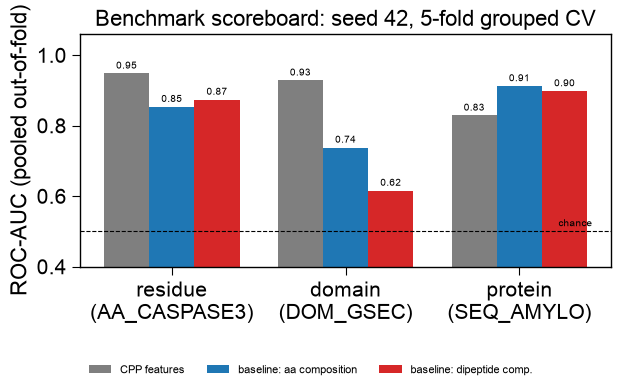

In [8]:
# Headline figure: the benchmark scoreboard.
aa.plot_settings(font_scale=0.9, weight_bold=False)
df_auc = df_bench[df_bench["metric"] == "roc_auc"]
kinds = ["cpp", "aac", "dpc"]
levels = ["residue", "domain", "protein"]
colors = aa.plot_get_clist(n_colors=3)

fig, ax = plt.subplots(figsize=(6.5, 4))
width = 0.26
x = np.arange(len(levels))
for i, kind in enumerate(kinds):
    vals = [float(df_auc[(df_auc["level"] == lv) & (df_auc["features"] == kind)]["score"].iloc[0])
            for lv in levels]
    bars = ax.bar(x + (i - 1) * width, vals, width, color=colors[i],
                  label={"cpp": "CPP features", "aac": "baseline: aa composition",
                         "dpc": "baseline: dipeptide comp."}[kind])
    ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)
ax.axhline(0.5, color="black", lw=0.8, ls="--")
ax.text(2.42, 0.515, "chance", fontsize=7, ha="right")
ax.set_xticks(x)
ax.set_xticklabels([f"{lv}\n({ds})" for lv, ds in zip(levels, df_registry["dataset"])])
ax.set_ylabel("ROC-AUC (pooled out-of-fold)")
ax.set_ylim(0.4, 1.06)
ax.set_title("Benchmark scoreboard: seed 42, 5-fold grouped CV")
fig.legend(*ax.get_legend_handles_labels(), frameon=False, fontsize=8, ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, 0.075))
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

**The concept the split makes visible: a group in both halves.** The score gap between a grouped and an ungrouped split is a weak way to see leakage, because on this set it happens to be small. The fold composition shows it directly. Below, the same five-fold split is cut twice over the same residue data: once ignoring proteins (`StratifiedKFold`, wrapped with `allow_overlap=True` so the guard permits it) and once respecting them (`StratifiedGroupKFold`).

Read the left panel: the ungrouped split puts **all 20 proteins in the training half and all 20 in the test half of every fold**. Every protein is on both sides of every boundary. The grouped split splits 16 against 4, with no protein shared. The right panel shows what that costs in score here, and the honest answer on this dataset is: very little. That is a finding, not a let-off. You cannot know the gap is small until you measure it, and on a set with more within-protein redundancy it will not be.

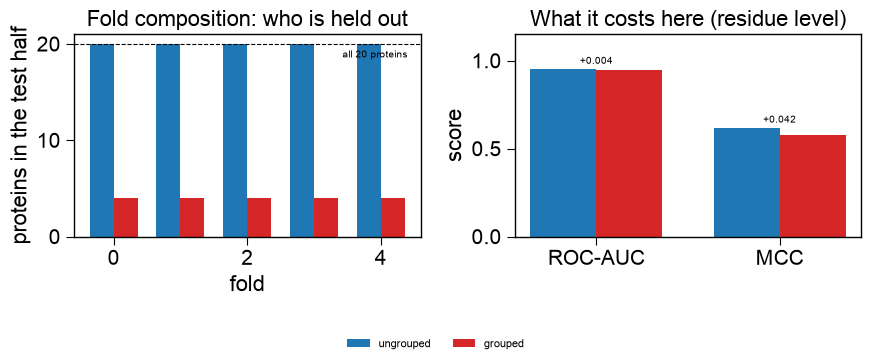

In [9]:
# Concept figure: what the grouped split changes, in fold composition and in score.
cv_leaky = aa.bind_groups(cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED),
                          groups=groups_res, allow_overlap=True)   # permitted, so it can be shown
cv_honest = pinned_cv(groups=groups_res)

scores = {}
for name, cv in [("ungrouped", cv_leaky), ("grouped", cv_honest)]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df_e = aa.AAPred(models=["rf"], verbose=False, random_state=SEED).eval(
            X_res, labels=labels_res, metrics=METRICS, cv=cv)
    scores[name] = {r.metric: float(r.score) for r in df_e.itertuples()}

aa.plot_settings(font_scale=0.9, weight_bold=False)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
c_leak, c_ok = aa.plot_get_clist(n_colors=2)

ax = axes[0]
folds = cv_leaky.df_folds_["fold"].to_numpy()
ax.bar(folds - 0.18, cv_leaky.df_folds_["n_groups_test"], 0.36, color=c_leak, label="ungrouped")
ax.bar(folds + 0.18, cv_honest.df_folds_["n_groups_test"], 0.36, color=c_ok, label="grouped")
ax.axhline(len(set(groups_res)), color="black", lw=0.8, ls="--")
ax.text(4.4, len(set(groups_res)) - 1.4, "all 20 proteins", fontsize=7, ha="right")
ax.set_xlabel("fold")
ax.set_ylabel("proteins in the test half")
ax.set_title("Fold composition: who is held out")

ax = axes[1]
xs = np.arange(len(METRICS))
ax.bar(xs - 0.18, [scores["ungrouped"][m] for m in METRICS], 0.36, color=c_leak, label="ungrouped")
ax.bar(xs + 0.18, [scores["grouped"][m] for m in METRICS], 0.36, color=c_ok, label="grouped")
for i, m in enumerate(METRICS):
    delta = scores["ungrouped"][m] - scores["grouped"][m]
    ax.text(i, max(scores["ungrouped"][m], scores["grouped"][m]) + 0.03,
            f"+{delta:.3f}" if delta > 0 else f"{delta:.3f}", ha="center", fontsize=7.5)
ax.set_xticks(xs)
ax.set_xticklabels(["ROC-AUC", "MCC"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("score")
ax.set_title("What it costs here (residue level)")
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, frameon=False, fontsize=8, ncol=2,
           loc="upper center", bbox_to_anchor=(0.5, 0.045))
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

Set `allow_overlap=False` (the default) and the same leaky splitter stops being a silent inflation and becomes an error that names the shared groups. This is the guard worth keeping on.

In [10]:
# The guard: the same leaky splitter with allow_overlap left at its default.
cv_guarded = aa.bind_groups(cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED),
                            groups=groups_res, allow_overlap=False)
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # StratifiedKFold notes that it ignores groups
        list(cv_guarded.split(X_res, labels_res))
    message = "no error raised"
except ValueError as err:
    message = str(err)
message

"'cv' put 20 group(s) in both train and test of fold 0 (e.g. 'CASPASE3_115'), which leaks between folds. Use a group-aware splitter (e.g. 'GroupKFold', 'StratifiedGroupKFold', 'LeaveOneGroupOut') or set 'allow_overlap=True' to permit it"

**The concept the seed makes visible: how far a score drifts on its own.** The fourth pinned decision is the seed, and it is what turns "the number moved" into "the method changed". Pin the seed and a rerun is bit-identical. Leave it free and the same unchanged method produces a spread, purely from where the fold boundaries fall and how the forest is grown.

That spread is not a nuisance, it is the measurement that sets the regression tolerance. Below, the protocol is rerun across ten seeds at every level: the cloud is the free-seed spread, the marker is the pinned seed 42 that the recorded table uses.

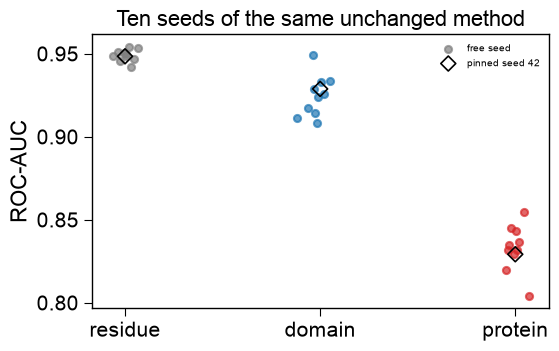

DataFrame shape: (3, 5)


,level,mean,std,min,max
1,domain,0.924600,0.012400,0.908300,0.949400
2,protein,0.833200,0.014000,0.804200,0.854700
3,residue,0.949100,0.003600,0.941800,0.954300


In [11]:
# Concept figure: the free-seed spread that sets the tolerance.
rows = []
for level, (X, labels, groups, _) in LEVELS.items():
    for seed in range(SEED, SEED + 10):
        aap = aa.AAPred(models=["rf"], verbose=False, random_state=seed)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            df_e = aap.eval(X, labels=labels, metrics=["roc_auc"],
                             cv=pinned_cv(groups=groups, seed=seed))
        rows.append({"level": level, "seed": seed, "roc_auc": float(df_e["score"].iloc[0])})
df_seeds = pd.DataFrame(rows)
df_spread = df_seeds.groupby("level")["roc_auc"].agg(["mean", "std", "min", "max"]).round(4)

aa.plot_settings(font_scale=0.9, weight_bold=False)
fig, ax = plt.subplots(figsize=(6, 3.8))
jitter = np.random.default_rng(0)
for i, level in enumerate(levels):
    vals = df_seeds[df_seeds["level"] == level]["roc_auc"].to_numpy()
    ax.scatter(i + jitter.normal(0, 0.05, size=len(vals)), vals, color=colors[i],
               alpha=0.7, s=26, label="free seed" if i == 0 else None)
    pinned = df_seeds[(df_seeds["level"] == level) & (df_seeds["seed"] == SEED)]["roc_auc"].iloc[0]
    ax.scatter([i], [pinned], marker="D", s=58, facecolor="none", edgecolor="black", lw=1.2,
               label="pinned seed 42" if i == 0 else None, zorder=5)
ax.set_xticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_ylabel("ROC-AUC")
ax.set_title("Ten seeds of the same unchanged method")
ax.legend(frameon=False, fontsize=7.5, loc="upper right")
plt.tight_layout()
plt.show()

aa.display_df(df=df_spread.reset_index(), n_rows=10, show_shape=True)

**The tolerance.** The widest across-seed standard deviation over the three levels is the protocol's noise floor. Rounding three standard deviations up to a round number gives the rule this protocol adopts:

> A drop of more than **0.05 absolute ROC-AUC** at any level, at the pinned seed, is a regression. Anything smaller is inside the noise the seed sweep just measured.

Deriving the tolerance from a measured spread is the whole point. A tolerance picked *a priori* is either so tight that ordinary seed jitter trips it on every unrelated pull request or so loose that a real regression slips through.

In [12]:
sigma_max = float(df_spread["std"].max())
{"widest across-seed std": round(sigma_max, 4),
 "three standard deviations": round(3 * sigma_max, 4),
 "adopted tolerance": TOLERANCE}

{'widest across-seed std': 0.014,
 'three standard deviations': 0.042,
 'adopted tolerance': 0.05}

**Reproducibility.** The protocol's central claim is that a rerun reproduces the table. Here it is, checked rather than asserted: the pinned procedure is run a second time from the same inputs and the two score vectors are compared exactly.

In [13]:
# Rerun the pinned procedure and compare the two score vectors exactly.
frames_again = []
for level, (X, labels, groups, df_seq) in LEVELS.items():
    aap = aa.AAPred(models=["rf"], verbose=False, random_state=SEED)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df_eval = aap.eval(X, labels=labels, metrics=METRICS, cv=pinned_cv(groups=groups),
                            df_seq=df_seq, baseline=["aac", "dpc"], list_parts="tmd_jmd")
    frames_again.append(df_eval.assign(level=level))
df_again = pd.concat(frames_again, ignore_index=True)[["level", "features", "metric",
                                                       "principle", "score"]]

identical = np.array_equal(df_bench["score"].to_numpy(), df_again["score"].to_numpy())
{"rerun reproduces every score exactly": bool(identical),
 "max absolute difference": float(np.abs(df_bench["score"].to_numpy()
                                         - df_again["score"].to_numpy()).max())}

{'rerun reproduces every score exactly': True, 'max absolute difference': 0.0}

**The residue level's own primary metric.** ROC-AUC over pooled windows answers "can the model tell a site from a non-site anywhere in the set". Site prediction is usually asked a harder question: *within one protein*, are the true sites ranked at the top? That is per-protein average precision, and `comp_per_protein_ap` computes it from per-protein score vectors and the 0-based indices of the true sites. It is reported alongside ROC-AUC because the two can move apart: a model can separate sites from non-sites globally and still rank badly inside individual proteins.

The scores are out-of-fold, taken through the same grouped splitter, so each protein is scored only by folds that never trained on it.

In [14]:
# Residue-level primary metric: per-protein average precision, out-of-fold.
oof = cross_val_predict(RandomForestClassifier(n_estimators=100, random_state=SEED),
                        X_res, labels_res, cv=pinned_cv(groups=groups_res),
                        method="predict_proba")[:, 1]
df_oof = df_res[["entry", "protein", "label"]].copy()
df_oof["position"] = df_oof["entry"].str.rsplit("_pos", n=1).str[1].astype(int)
df_oof["score"] = oof

list_scores, list_positions = [], []
for _, df_p in df_oof.sort_values("position").groupby("protein", sort=True):
    list_scores.append(df_p["score"].to_numpy())
    list_positions.append(np.flatnonzero(df_p["label"].to_numpy() == 1))

ap = aa.comp_per_protein_ap(list_scores=list_scores, list_positions=list_positions, tolerance=0)
{"n proteins": int(len(ap)), "per-protein AP (mean)": round(float(np.nanmean(ap)), 4)}

{'n proteins': 20, 'per-protein AP (mean)': 0.8003}

In [15]:
# The recorded baseline table: what a future rerun is diffed against.
df_record = (df_bench[df_bench["metric"] == "roc_auc"]
             .pivot(index="level", columns="features", values="score")
             .reindex(levels)[["cpp", "aac", "dpc"]]
             .round(4)
             .reset_index())
df_record["best baseline"] = df_record[["aac", "dpc"]].max(axis=1).round(4)
df_record["cpp - baseline"] = (df_record["cpp"] - df_record["best baseline"]).round(4)
df_record["tolerance"] = TOLERANCE
aa.display_df(df=df_record, n_rows=10, show_shape=True)

DataFrame shape: (3, 7)


features,level,cpp,aac,dpc,best baseline,cpp - baseline,tolerance
1,residue,0.948500,0.854000,0.874400,0.874400,0.074100,0.050000
2,domain,0.928900,0.738300,0.616100,0.738300,0.190600,0.050000
3,protein,0.829300,0.912800,0.898500,0.912800,-0.083500,0.050000


**How to interpret.** Read the recorded table as a baseline, not as an achievement.

| What you see | What it means |
| --- | --- |
| a delta inside +/- 0.05 | noise, at the measured seed spread; not a change |
| a drop beyond 0.05 at one level | a regression at that level; the other levels do not excuse it |
| `cpp` below a composition baseline | positional features do not earn their keep on that task |
| a grouped score far below its ungrouped twin | the samples are more dependent than assumed |
| `holdout` far from `cv_pooled` | the held-out slice is too small to estimate anything |

**Key takeaways**

- **A benchmark is a frozen procedure, not a dataset.** The four pinned decisions (dataset, split, metric, seed) are the deliverable; the shipped tables were always there.
- **The tolerance has to be measured.** The across-seed spread is the noise floor, and a regression threshold below it only produces false alarms.
- **Grouping is a property you verify, not assume.** `df_folds_` states it per fold, and `allow_overlap=False` turns a violated assumption into an error instead of an inflated score.

**Common mistakes.**

- **Using `random=True` for a benchmark.** It takes no seed and `aa.options["random_state"]` does not reach it, so the set changes under you between runs. Pin `random=False` and subsample with your own seeded generator.
- **Reading `len(df_seq)` as the group size.** `load_dataset(n=N)` returns `2N` rows; take counts from the `label` column.
- **Splitting residue windows without groups.** Windows share proteins, so a plain `KFold` puts the same protein on both sides of every fold. Bind the accession with `aa.bind_groups` and leave `allow_overlap=False`.
- **Comparing against a baseline built over a different span.** A baseline over `tmd_jmd` and a CPP matrix over `tmd` measure different residues, so the delta is geometry, not method. Match `list_parts` to the matrix.
- **Quoting the absolute score as a generalization estimate.** Feature selection here runs once on the full set, so the number is post-selection and optimistic. It is a valid yardstick for comparing runs, not an estimate of held-out performance.
- **Setting a tolerance tighter than the seed spread.** It will fire on unrelated changes until everyone learns to ignore it.
- **Using `comp_auc_adjusted` to score a model.** It ranks features; use `roc_auc` for a classifier.

**Next step.** Two directions from here. To ask whether a single result is real rather than comparable, go to *P10: Validation*, which adds the shuffled-label control and the bootstrap interval this protocol deliberately leaves out. To change something and measure it, rerun this notebook unchanged, diff the recorded table against the one committed here, and read the deltas against the 0.05 tolerance.